# CCB Foil Analysis - March 2026

Per-foil rotation, translation, and improved circle detection for:
- **Pre-irradiation** (2026-03-17): foils 1, 2
- **Irradiation** (2026-03-19): foils 1, 2, 3, 4

No foil merging is performed. Each foil is centred in a 20×20 mm image.

Data is loaded from the NPZ files saved by the explore notebooks.

In [5]:
import sys
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import minimize

from src.data.analysis import Circle
from src.data.matching import (
    find_edge_crossings, fit_edge_line, rotate_image, rotate_circle,
    crop_centered,
)


## Configuration

In [7]:
# Base data path
DATA_BASE_PATH = Path(
    r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb"
)

# NPZ files produced by the explore notebooks
PRE_IRRAD_DATE = "2026-03-17"
IRRAD_DATE     = "2026-03-19"
PRE_IRRAD_NPZ = DATA_BASE_PATH / PRE_IRRAD_DATE / f'foils_ccb_processed_{PRE_IRRAD_DATE}.npz'
IRRAD_NPZ     = DATA_BASE_PATH / IRRAD_DATE     / f'foils_ccb_processed_{IRRAD_DATE}.npz'

# Foil IDs to analyse (must exist in the NPZ files)
PRE_IRRAD_FOIL_IDS = [1, 2]
IRRAD_FOIL_IDS     = [1, 2, 3, 4]

PIXEL_SIZE_MM = 0.074  # mm per pixel (74 µm)

# Crop: 20×20 mm centred on each foil
CROP_MM     = 20.0
CROP_SIZE_PX = int(CROP_MM / PIXEL_SIZE_MM)  # ~270 px

# Edge detection parameters (used for rotation correction)
EDGE_THRESHOLD   = 400.0
EDGE_X_POSITIONS = [240, 260, 280, 300, 320, 340, 360]
EDGE_STRIPE_WIDTH = 10

# Gradient-based circle refinement
CIRCLE_GRADIENT_HIGH     = 300
CIRCLE_GRADIENT_LOW      = 200
CIRCLE_EDGE_DISTANCE_MM  = 0.5
CIRCLE_RADIUS_TOLERANCE  = 0.05

# Visualisation
VMAX             = 3000
WHITE_THRESHOLD  = 0.05
CONTOUR_LEVELS   = [600, 800, 1000, 1200, 1400, 1600]
STRIP_WIDTH_MM   = 1.0
PROFILE_OFFSETS_MM = [-4, 0, 4]  # Y offsets from foil centre

CMAP = LinearSegmentedColormap.from_list('white_green_red', [
    (0.0,            (1.0, 1.0, 1.0, 1.0)),
    (WHITE_THRESHOLD,(1.0, 1.0, 1.0, 1.0)),
    (0.5,            (0.0, 1.0, 0.0, 1.0)),
    (1.0,            (1.0, 0.0, 0.0, 1.0)),
])

print(f'CROP_SIZE_PX = {CROP_SIZE_PX} px  ({CROP_SIZE_PX * PIXEL_SIZE_MM:.1f} mm)')
print(f'Pre-irrad NPZ: {PRE_IRRAD_NPZ}')
print(f'Irrad NPZ:     {IRRAD_NPZ}')


CROP_SIZE_PX = 270 px  (20.0 mm)
Pre-irrad NPZ: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-03-17\foils_ccb_processed_2026-03-17.npz
Irrad NPZ:     C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2026-03-19\foils_ccb_processed_2026-03-19.npz


## Load Foil Data from Explore Notebooks

In [9]:
# Load pre-irradiation data
pre_data = np.load(PRE_IRRAD_NPZ, allow_pickle=False)
print(f'pre-irradiation NPZ keys: {list(pre_data.keys())}')

pre_data_images  = {}
pre_data_circles = {}
for fid in PRE_IRRAD_FOIL_IDS:
    key_img = f'image_{fid}'
    if key_img not in pre_data:
        print(f'  Warning: foil {fid} not found in NPZ')
        continue
    pre_data_images[fid]  = pre_data[key_img]
    pre_data_circles[fid] = Circle(
        x=float(pre_data[f'circle_x_{fid}']),
        y=float(pre_data[f'circle_y_{fid}']),
        r=float(pre_data[f'circle_r_{fid}']),
    )
    img_shape = pre_data_images[fid].shape
    c = pre_data_circles[fid]
    print(f'  Foil {fid}: image {img_shape}, circle ({c.x:.1f}, {c.y:.1f}, r={c.r:.1f})')


pre-irradiation NPZ keys: ['pixel_size_mm', 'foil_ids', 'image_1', 'circle_x_1', 'circle_y_1', 'circle_r_1', 'image_2', 'circle_x_2', 'circle_y_2', 'circle_r_2']
  Foil 1: image (424, 424), circle (233.5, 199.5, r=130.6)
  Foil 2: image (424, 424), circle (228.5, 188.5, r=133.7)


In [10]:
# Load irradiation data
irrad_data = np.load(IRRAD_NPZ, allow_pickle=False)
print(f'irradiation NPZ keys: {list(irrad_data.keys())}')

irrad_data_images  = {}
irrad_data_circles = {}
for fid in IRRAD_FOIL_IDS:
    key_img = f'image_{fid}'
    if key_img not in irrad_data:
        print(f'  Warning: foil {fid} not found in NPZ')
        continue
    irrad_data_images[fid]  = irrad_data[key_img]
    irrad_data_circles[fid] = Circle(
        x=float(irrad_data[f'circle_x_{fid}']),
        y=float(irrad_data[f'circle_y_{fid}']),
        r=float(irrad_data[f'circle_r_{fid}']),
    )
    img_shape = irrad_data_images[fid].shape
    c = irrad_data_circles[fid]
    print(f'  Foil {fid}: image {img_shape}, circle ({c.x:.1f}, {c.y:.1f}, r={c.r:.1f})')


irradiation NPZ keys: ['pixel_size_mm', 'foil_ids', 'image_1', 'circle_x_1', 'circle_y_1', 'circle_r_1', 'image_2', 'circle_x_2', 'circle_y_2', 'circle_r_2', 'image_3', 'circle_x_3', 'circle_y_3', 'circle_r_3', 'image_4', 'circle_x_4', 'circle_y_4', 'circle_r_4']
  Foil 1: image (424, 424), circle (232.5, 194.5, r=135.3)
  Foil 2: image (424, 424), circle (232.5, 194.5, r=135.7)
  Foil 3: image (424, 424), circle (231.5, 197.5, r=137.3)
  Foil 4: image (424, 424), circle (234.5, 197.5, r=129.6)


## Processing Functions

In [11]:
def find_gradient_edge_points(image, high_thresh, low_thresh):
    """Find points where intensity drops from high_thresh to low_thresh (radial scan)."""
    h, w = image.shape
    cy, cx = h // 2, w // 2
    edge_points = []
    n_angles = 360
    for angle_idx in range(n_angles):
        angle = 2 * np.pi * angle_idx / n_angles
        max_radius = min(h, w) // 2
        prev_val = None
        in_transition = False
        transition_start = None
        for r in range(10, max_radius):
            x = int(cx + r * np.cos(angle))
            y = int(cy + r * np.sin(angle))
            if 0 <= x < w and 0 <= y < h:
                val = image[y, x]
                if prev_val is not None:
                    if not in_transition and prev_val > high_thresh and val <= high_thresh:
                        in_transition = True
                        transition_start = (x, y)
                    if in_transition and val < low_thresh:
                        if transition_start is not None:
                            mid_x = (transition_start[0] + x) // 2
                            mid_y = (transition_start[1] + y) // 2
                            edge_points.append((mid_x, mid_y))
                        in_transition = False
                        transition_start = None
                        break
                prev_val = val
    return edge_points


def filter_edge_points_near_circle(edge_points, circle, max_distance_px):
    """Keep only edge points within max_distance_px of the circle boundary."""
    filtered = []
    for x, y in edge_points:
        dist = abs(np.sqrt((x - circle.x)**2 + (y - circle.y)**2) - circle.r)
        if dist <= max_distance_px:
            filtered.append((x, y))
    return filtered


def fit_circle_to_points(points, initial_circle, radius_tolerance):
    """Fit a circle to edge points with radius constrained to ±radius_tolerance."""
    if len(points) < 10:
        return initial_circle
    pts = np.array(points)
    xp, yp = pts[:, 0], pts[:, 1]
    min_r = initial_circle.r * (1 - radius_tolerance)
    max_r = initial_circle.r * (1 + radius_tolerance)

    def objective(params):
        cx, cy, r = params
        return np.sum((np.sqrt((xp - cx)**2 + (yp - cy)**2) - r)**2)

    x0 = [initial_circle.x, initial_circle.y, initial_circle.r]
    result = minimize(objective, x0, method='L-BFGS-B',
                      bounds=[(None, None), (None, None), (min_r, max_r)])
    return Circle(x=result.x[0], y=result.x[1], r=result.x[2])


In [12]:
def process_foil(image, circle, foil_id, label=''):
    """
    Full pipeline for a single foil:
      1. Edge detection → rotation (corrects scanner tilt)
      2. Crop 20×20 mm centred on circle (translation)
      3. Gradient-based circle refinement

    Returns dict with keys: image, circle_initial, circle_refined, rot_angle
    """
    tag = f'{label} foil {foil_id}'

    # ── Rotation ────────────────────────────────────────────────────────
    crossings = find_edge_crossings(image, EDGE_X_POSITIONS, EDGE_THRESHOLD, EDGE_STRIPE_WIDTH)
    valid = [(x, y) for x, y in crossings if y is not None]
    if len(valid) >= 3:
        line = fit_edge_line(crossings, robust=True)
        rot_angle = line.slope_deg + 90
        print(f'{tag}: edge slope {line.slope_deg:.3f}°  →  rotate {rot_angle:.3f}°')
    else:
        rot_angle = 0.0
        print(f'{tag}: edge detection failed ({len(valid)} pts) — no rotation')

    img_rot    = rotate_image(image, rot_angle)
    circle_rot = rotate_circle(circle, image.shape, -rot_angle)

    # ── Crop centred on circle (translation) ────────────────────────────
    img_crop, offset = crop_centered(img_rot, circle_rot.x, circle_rot.y, CROP_SIZE_PX)
    circle_crop = Circle(
        x=circle_rot.x - offset[0],
        y=circle_rot.y - offset[1],
        r=circle_rot.r,
    )

    # ── Gradient circle refinement ───────────────────────────────────────
    edge_pts = find_gradient_edge_points(img_crop, CIRCLE_GRADIENT_HIGH, CIRCLE_GRADIENT_LOW)
    max_dist_px = CIRCLE_EDGE_DISTANCE_MM / PIXEL_SIZE_MM
    filtered   = filter_edge_points_near_circle(edge_pts, circle_crop, max_dist_px)

    if len(filtered) >= 10:
        circle_ref = fit_circle_to_points(filtered, circle_crop, CIRCLE_RADIUS_TOLERANCE)
        dx = (circle_ref.x - circle_crop.x) * PIXEL_SIZE_MM
        dy = (circle_ref.y - circle_crop.y) * PIXEL_SIZE_MM
        dr = (circle_ref.r - circle_crop.r) * PIXEL_SIZE_MM
        print(f'{tag}: circle refined  Δcenter=({dx:+.3f},{dy:+.3f}) mm  Δr={dr:+.3f} mm')
    else:
        circle_ref = circle_crop
        print(f'{tag}: too few edge pts ({len(filtered)}) — using initial circle')

    return dict(image=img_crop, circle_initial=circle_crop,
                circle_refined=circle_ref, rot_angle=rot_angle)


## Visualisation Functions

In [13]:
def plot_foil_2d(ax, image, circle, pixel_size_mm, title, vmax, contour_levels, cmap):
    """Plot 2D isosignal map centred on the foil circle."""
    h, w = image.shape
    cx_mm = circle.x * pixel_size_mm
    cy_mm = circle.y * pixel_size_mm

    # Coordinate arrays centred on refined circle
    x_arr = np.arange(w) * pixel_size_mm - cx_mm
    y_arr = np.arange(h) * pixel_size_mm - cy_mm

    extent = [x_arr[0], x_arr[-1], y_arr[-1], y_arr[0]]  # [left, right, bottom, top]
    im = ax.imshow(image, cmap=cmap, vmin=0, vmax=vmax, extent=extent, origin='upper')

    cs = ax.contour(x_arr, y_arr, image, levels=contour_levels,
                    colors='black', linewidths=0.8)
    ax.clabel(cs, inline=True, fontsize=8, fmt='%d')

    # Circle overlay (refined = solid black, initial = dashed blue)
    ax.add_patch(plt.Circle((0, 0), circle.r * pixel_size_mm,
                            color='black', fill=False, lw=1.5))
    ax.plot(0, 0, 'k+', ms=12, mew=2)

    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Y [mm]')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlim(-CROP_MM / 2, CROP_MM / 2)
    ax.set_ylim(CROP_MM / 2, -CROP_MM / 2)  # y downward
    return im


def plot_foil_profiles(ax, image, circle, pixel_size_mm, title, vmax,
                       strip_width_mm, offsets_mm):
    """Plot horizontal profiles at several Y offsets from the foil centre."""
    h, w = image.shape
    cx_mm = circle.x * pixel_size_mm
    cy_mm = circle.y * pixel_size_mm
    x_arr = np.arange(w) * pixel_size_mm - cx_mm
    strip_half = max(1, int((strip_width_mm / 2) / pixel_size_mm))

    for offset in offsets_mm:
        y_px = int((cy_mm + offset) / pixel_size_mm)
        y0 = max(0, y_px - strip_half)
        y1 = min(h, y_px + strip_half + 1)
        profile = np.nanmean(image[y0:y1, :].astype(float), axis=0)
        ax.plot(x_arr, profile, lw=1.5,
                label=f'Y = {offset:+.0f} mm  (row {y_px})')

    ax.set_xlim(-CROP_MM / 2, CROP_MM / 2)
    ax.set_ylim(0, vmax)
    ax.set_xlabel('X [mm]')
    ax.set_ylabel('Intensity')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


## Pre-Irradiation Foils (2026-03-17)

In [14]:
pre_processed = {}
for fid in PRE_IRRAD_FOIL_IDS:
    if fid not in pre_data_images:
        continue
    result = process_foil(
        image=pre_data_images[fid],
        circle=pre_data_circles[fid],
        foil_id=fid,
        label='pre-irrad',
    )
    pre_processed[fid] = result
print(f'Processed {len(pre_processed)} pre-irrad foils.')


pre-irrad foil 1: edge slope -45.993°  →  rotate 44.007°
pre-irrad foil 1: circle refined  Δcenter=(-0.113,-0.027) mm  Δr=-0.346 mm
pre-irrad foil 2: edge detection failed (2 pts) — no rotation
pre-irrad foil 2: too few edge pts (6) — using initial circle
Processed 2 pre-irrad foils.


### Pre-Irrad — 2D Signal Visualization

Isosignal contour lines centred on each foil (20×20 mm).

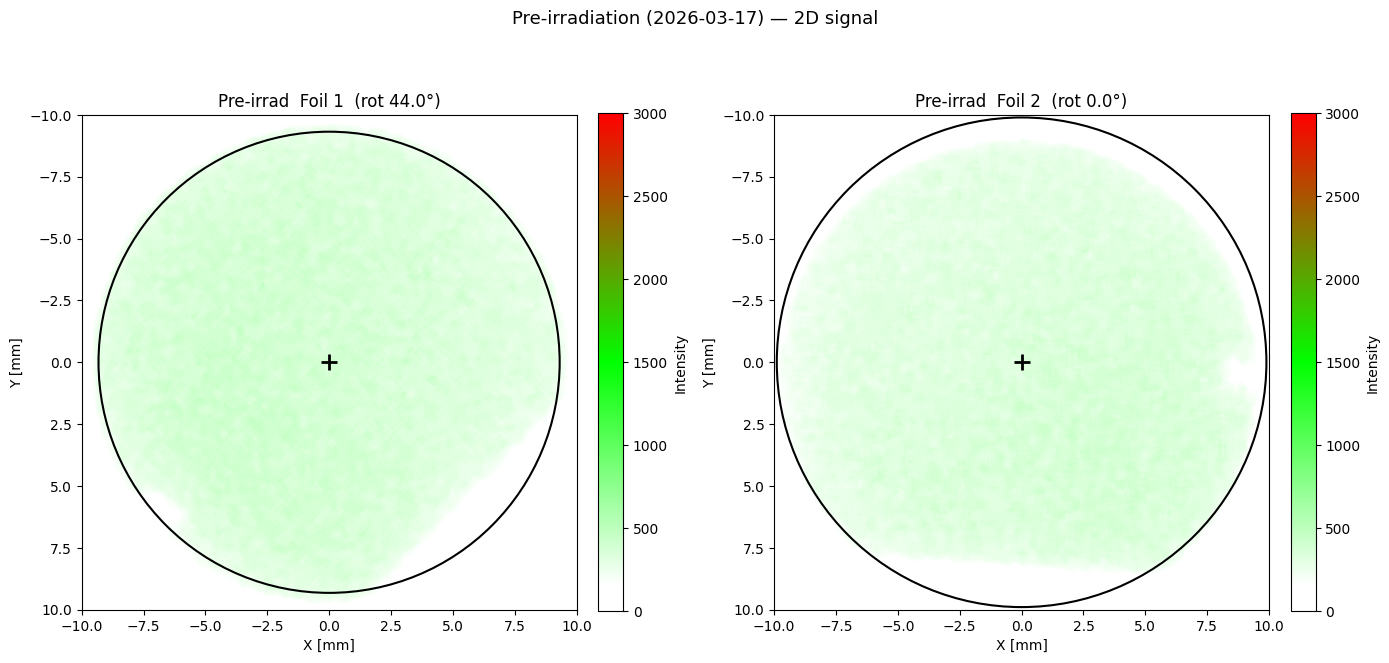

In [15]:
n = len(pre_processed)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]
for ax, (fid, res) in zip(axes, pre_processed.items()):
    im = plot_foil_2d(
        ax, res['image'], res['circle_refined'],
        PIXEL_SIZE_MM,
        title=f'Pre-irrad  Foil {fid}  (rot {res["rot_angle"]:.1f}°)',
        vmax=VMAX, contour_levels=CONTOUR_LEVELS, cmap=CMAP,
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Intensity')
plt.suptitle(f'Pre-irradiation ({PRE_IRRAD_DATE}) — 2D signal', fontsize=13)
plt.tight_layout()
plt.show()


### Pre-Irrad — Horizontal Profiles

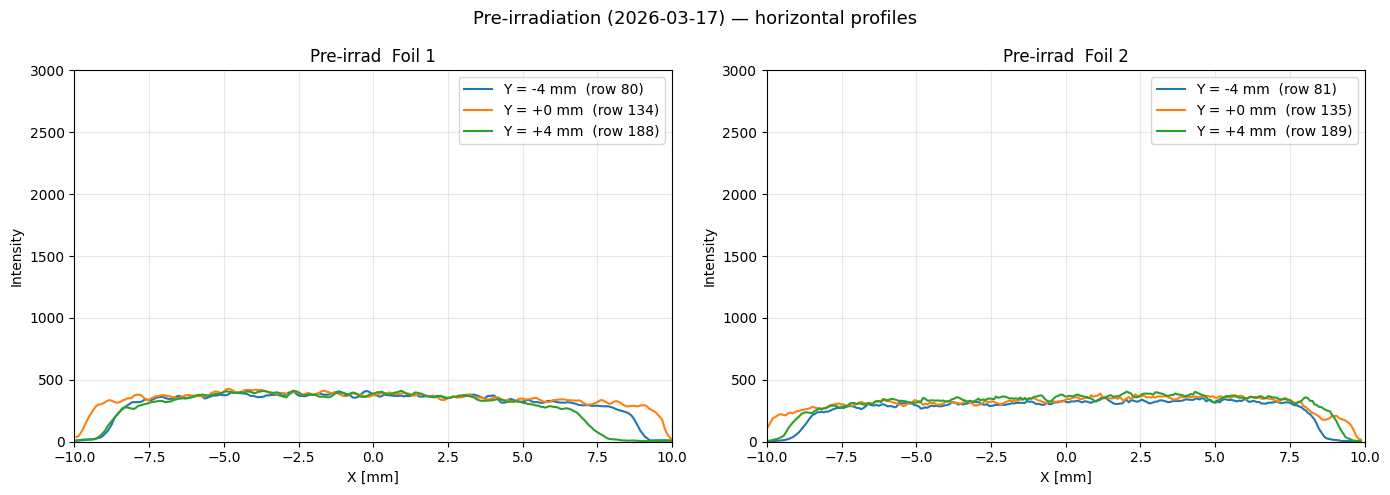

In [16]:
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
if n == 1:
    axes = [axes]
for ax, (fid, res) in zip(axes, pre_processed.items()):
    plot_foil_profiles(
        ax, res['image'], res['circle_refined'],
        PIXEL_SIZE_MM,
        title=f'Pre-irrad  Foil {fid}',
        vmax=VMAX, strip_width_mm=STRIP_WIDTH_MM, offsets_mm=PROFILE_OFFSETS_MM,
    )
plt.suptitle(f'Pre-irradiation ({PRE_IRRAD_DATE}) — horizontal profiles', fontsize=13)
plt.tight_layout()
plt.show()


## Irradiation Foils (2026-03-19)

In [17]:
irrad_processed = {}
for fid in IRRAD_FOIL_IDS:
    if fid not in irrad_data_images:
        continue
    result = process_foil(
        image=irrad_data_images[fid],
        circle=irrad_data_circles[fid],
        foil_id=fid,
        label='irrad',
    )
    irrad_processed[fid] = result
print(f'Processed {len(irrad_processed)} irrad foils.')


irrad foil 1: edge slope -28.253°  →  rotate 61.747°
irrad foil 1: circle refined  Δcenter=(+0.132,+0.026) mm  Δr=-0.196 mm
irrad foil 2: edge slope -26.332°  →  rotate 63.668°
irrad foil 2: circle refined  Δcenter=(+0.103,+0.055) mm  Δr=-0.229 mm
irrad foil 3: edge slope -29.415°  →  rotate 60.585°
irrad foil 3: circle refined  Δcenter=(+0.161,-0.045) mm  Δr=-0.320 mm
irrad foil 4: edge slope -26.731°  →  rotate 63.269°
irrad foil 4: circle refined  Δcenter=(+0.011,-0.191) mm  Δr=+0.069 mm
Processed 4 irrad foils.


### Irradiation — 2D Signal Visualization

Isosignal contour lines centred on each foil (20×20 mm).

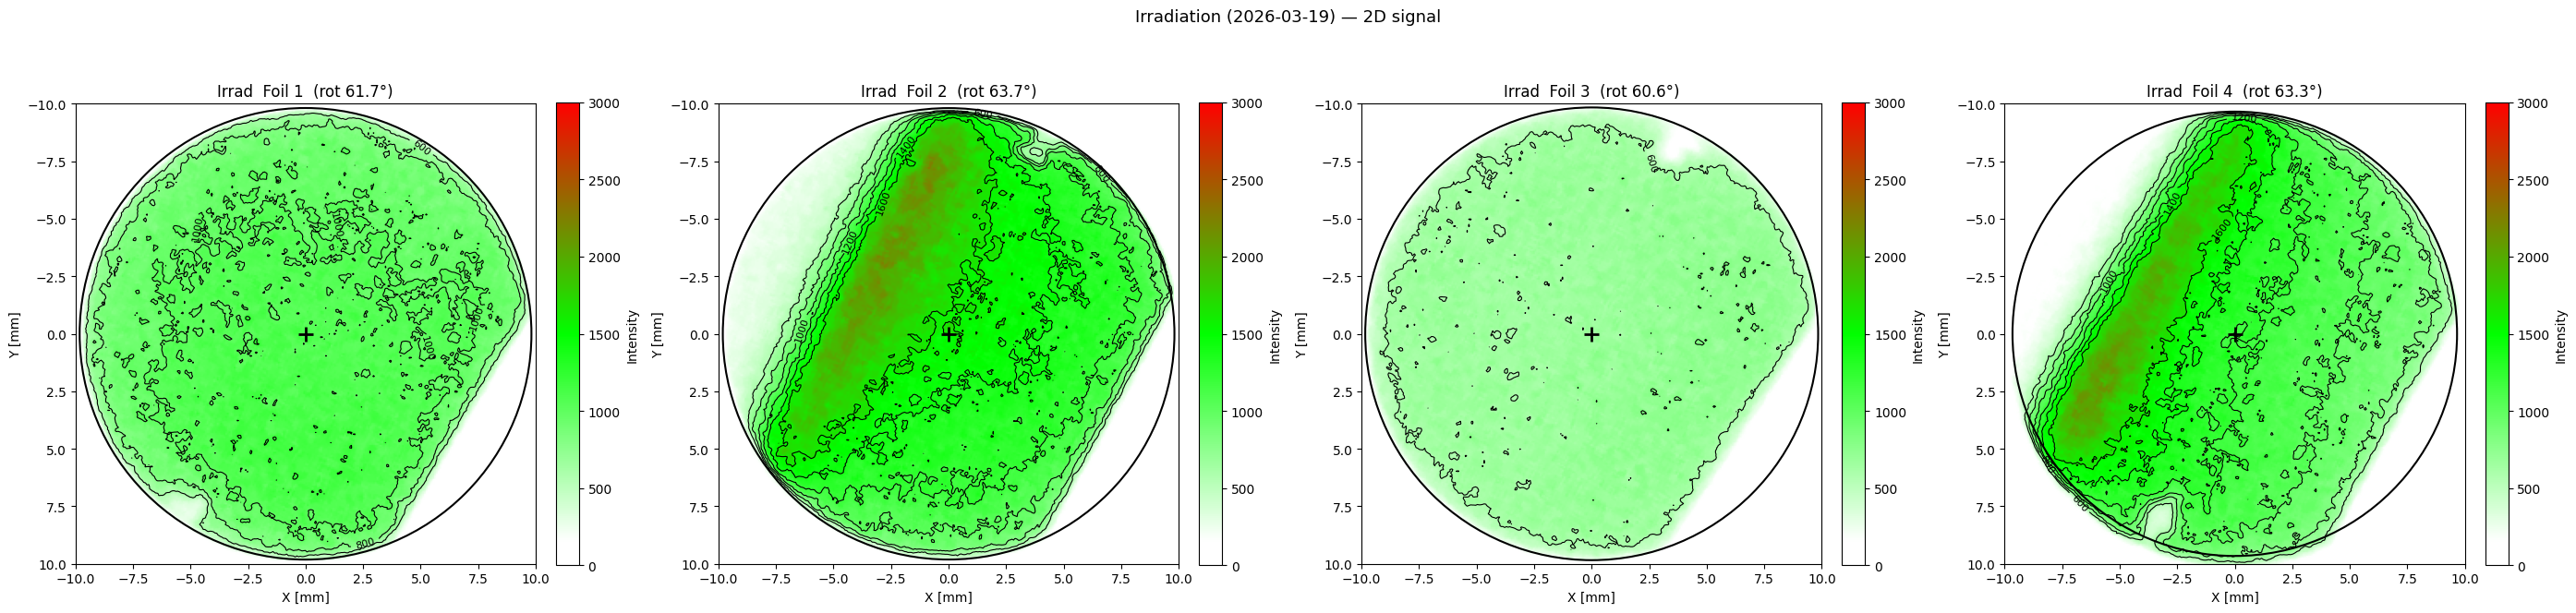

In [18]:
n = len(irrad_processed)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 7))
if n == 1:
    axes = [axes]
for ax, (fid, res) in zip(axes, irrad_processed.items()):
    im = plot_foil_2d(
        ax, res['image'], res['circle_refined'],
        PIXEL_SIZE_MM,
        title=f'Irrad  Foil {fid}  (rot {res["rot_angle"]:.1f}°)',
        vmax=VMAX, contour_levels=CONTOUR_LEVELS, cmap=CMAP,
    )
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Intensity')
plt.suptitle(f'Irradiation ({IRRAD_DATE}) — 2D signal', fontsize=13)
plt.tight_layout()
plt.show()


### Irradiation — Horizontal Profiles

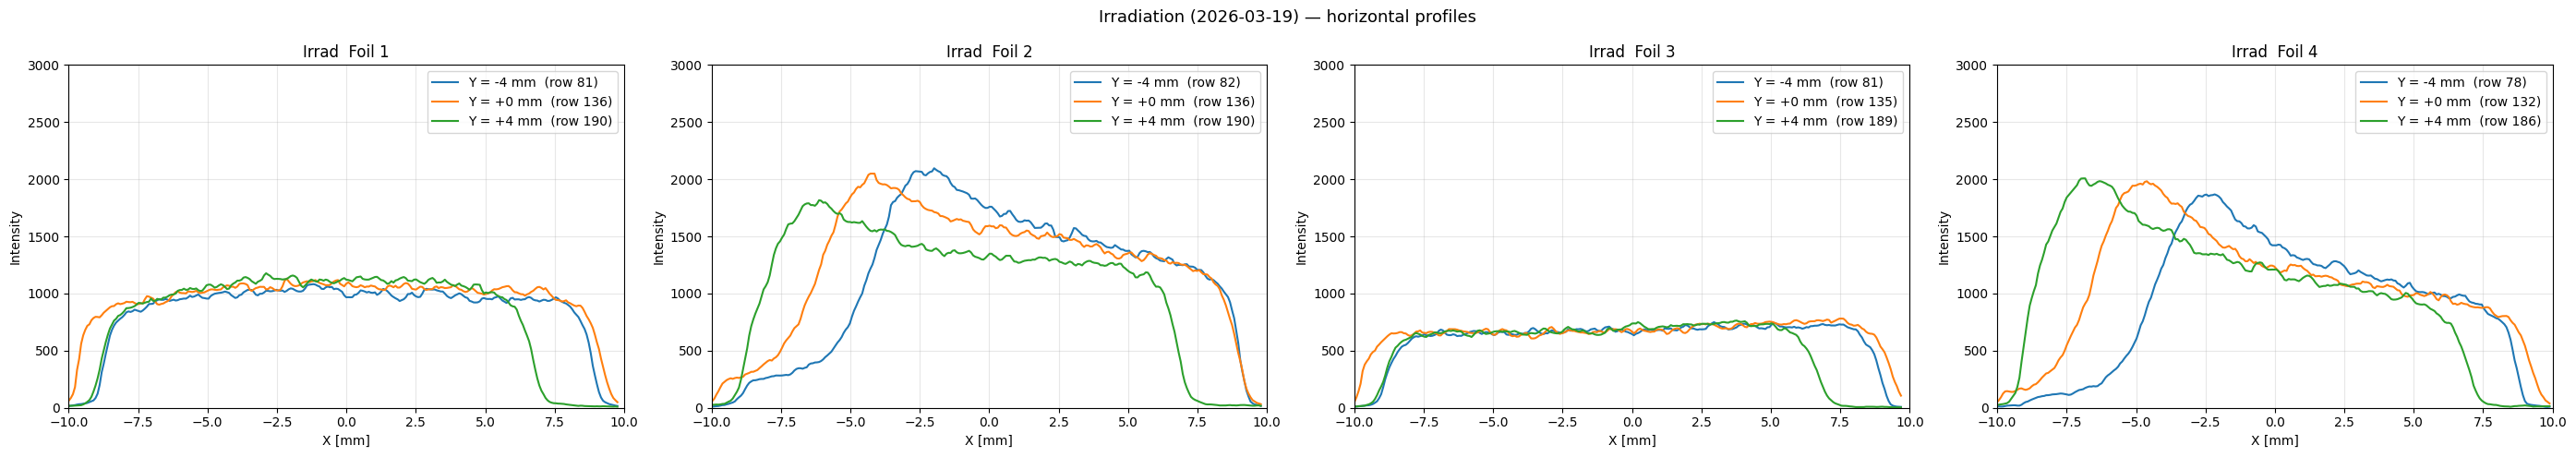

In [19]:
fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
if n == 1:
    axes = [axes]
for ax, (fid, res) in zip(axes, irrad_processed.items()):
    plot_foil_profiles(
        ax, res['image'], res['circle_refined'],
        PIXEL_SIZE_MM,
        title=f'Irrad  Foil {fid}',
        vmax=VMAX, strip_width_mm=STRIP_WIDTH_MM, offsets_mm=PROFILE_OFFSETS_MM,
    )
plt.suptitle(f'Irradiation ({IRRAD_DATE}) — horizontal profiles', fontsize=13)
plt.tight_layout()
plt.show()


## Save Results

Saves the processed (rotated + cropped + circle-refined) foil images and metadata
for both datasets into a single NPZ file per dataset.

In [ ]:
def save_processed_npz(processed_dict, date_str, pixel_size_mm):
    out = DATA_BASE_PATH / date_str / f'foils_ccb_analyzed_{date_str}.npz'
    npz_data = dict(pixel_size_mm=pixel_size_mm, foil_ids=np.array(sorted(processed_dict)))
    for fid, res in processed_dict.items():
        npz_data[f'image_{fid}']             = res['image']
        npz_data[f'circle_init_x_{fid}']     = np.float64(res['circle_initial'].x)
        npz_data[f'circle_init_y_{fid}']     = np.float64(res['circle_initial'].y)
        npz_data[f'circle_init_r_{fid}']     = np.float64(res['circle_initial'].r)
        npz_data[f'circle_refined_x_{fid}']  = np.float64(res['circle_refined'].x)
        npz_data[f'circle_refined_y_{fid}']  = np.float64(res['circle_refined'].y)
        npz_data[f'circle_refined_r_{fid}']  = np.float64(res['circle_refined'].r)
        npz_data[f'rot_angle_{fid}']          = np.float64(res['rot_angle'])
    np.savez(out, **npz_data)
    print(f'Saved {len(processed_dict)} foils → {out}')
    return out


pre_out  = save_processed_npz(pre_processed,   PRE_IRRAD_DATE, PIXEL_SIZE_MM)
irrad_out = save_processed_npz(irrad_processed, IRRAD_DATE,    PIXEL_SIZE_MM)
